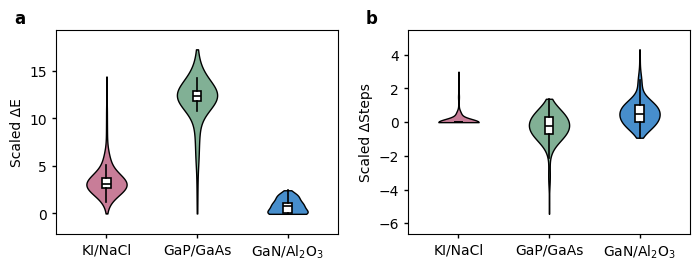

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

csv_paths = ["../dft_results/KI_NaCl.csv", "../dft_results/GaP_GaAs.csv", "../dft_results/GaN_Al2O3.csv"]
labels = ["KI/NaCl", "GaP/GaAs", "GaN/Al$_2$O$_3$"]

energy_col = "relaxed_energy"
steps_col = "convergence_steps"

top_k = 8
n_draws = 10000

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

colors = ["#C87D98", "#81B095", "#478ECC"]

def load_df(p):
    df = pd.read_csv(p).iloc[:24].copy()
    df[energy_col] = pd.to_numeric(df[energy_col], errors="coerce")
    df[steps_col] = pd.to_numeric(df[steps_col], errors="coerce")
    return df.dropna()

def simulate(df, seed):
    rng = np.random.default_rng(seed)
    top = df.iloc[:top_k]

    # Use median energy instead of minimum energy
    e_ref = np.median(top[energy_col].to_numpy(dtype=float))
    s_ref = np.median(top[steps_col].to_numpy(dtype=float))

    rel_e = []
    rel_s = []
    for _ in range(n_draws):
        idx = rng.choice(len(df), top_k, replace=False)
        d = df.iloc[idx]
        rel_e.append(np.median(d[energy_col].to_numpy(dtype=float)) - e_ref)
        rel_s.append(np.median(d[steps_col].to_numpy(dtype=float)) - s_ref)

    rel_e = np.array(rel_e, dtype=float)
    rel_s = np.array(rel_s, dtype=float)

    def scale(x):
        q1, q3 = np.percentile(x, [25, 75])
        iqr = q3 - q1
        return x / iqr if iqr > 0 else x

    return scale(rel_e), scale(rel_s)

dfs = [load_df(p) for p in csv_paths]
res = [simulate(df, 42 + i) for i, df in enumerate(dfs)]

E = [r[0] for r in res]
S = [r[1] for r in res]

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0))

def plot(ax, data, ylabel, label):
    pos = np.arange(len(data)) * 0.9

    vp = ax.violinplot(
    data,
    positions=pos,
    widths=0.4,
    bw_method=0.6,      # 🔥 关键：比你现在更大
    points=400,         # 🔥 更细腻
    showextrema=False
)
    for b, c in zip(vp["bodies"], colors):
        b.set_facecolor(c)
        b.set_edgecolor("black")
        b.set_linewidth(1.0)
        b.set_alpha(1.0)

    bp = ax.boxplot(
        data,
        positions=pos,
        widths=0.08,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor="white", edgecolor="black", linewidth=1.2),
        medianprops=dict(color="black", linewidth=1.2),
        whiskerprops=dict(color="black", linewidth=1.2),
        capprops=dict(linewidth=0)
    )

    # Ensure median lines stay visible above the boxes/bodies
    for med in bp["medians"]:
        med.set_zorder(4)

    ax.set_xticks(pos)
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)

    ax.tick_params(direction="out", length=3, width=1)

    ax.text(
        -0.15, 1.03, label,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold"
    )

    allv = np.concatenate(data)
    lo, hi = np.min(allv), np.max(allv)
    span = hi - lo
    pad = max(0.12 * span, 0.08)
    ax.set_ylim(lo - pad, hi + pad)

plot(axes[0], E, "Scaled ΔE", "a")
plot(axes[1], S, "Scaled ΔSteps", "b")

plt.subplots_adjust(left=0.1, right=0.98, bottom=0.22, top=0.9, wspace=0.25)
plt.savefig("fgw_violin_final_v3.pdf", bbox_inches="tight")
plt.show()
